# Black–Scholes Pricing & Moments

This notebook analyses the standard Black–Scholes model in isolation: price/volatility surfaces, parameter sensitivity, and distribution moments. It mirrors the Heston analysis so we can compare the two frameworks before calibration.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.black_scholes_model import BlackScholesModel

# Research paper quality plotting settings
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Color palette for research papers
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#C73E1D',
    'neutral': '#6C757D',
    'dark': '#212529',
}

## Baseline configuration


In [2]:
S0 = 100
sigma = 0.2
r = 0.02
q = 0.0

bs = BlackScholesModel(sigma=sigma, r=r, q=q)

## Price & volatility surfaces


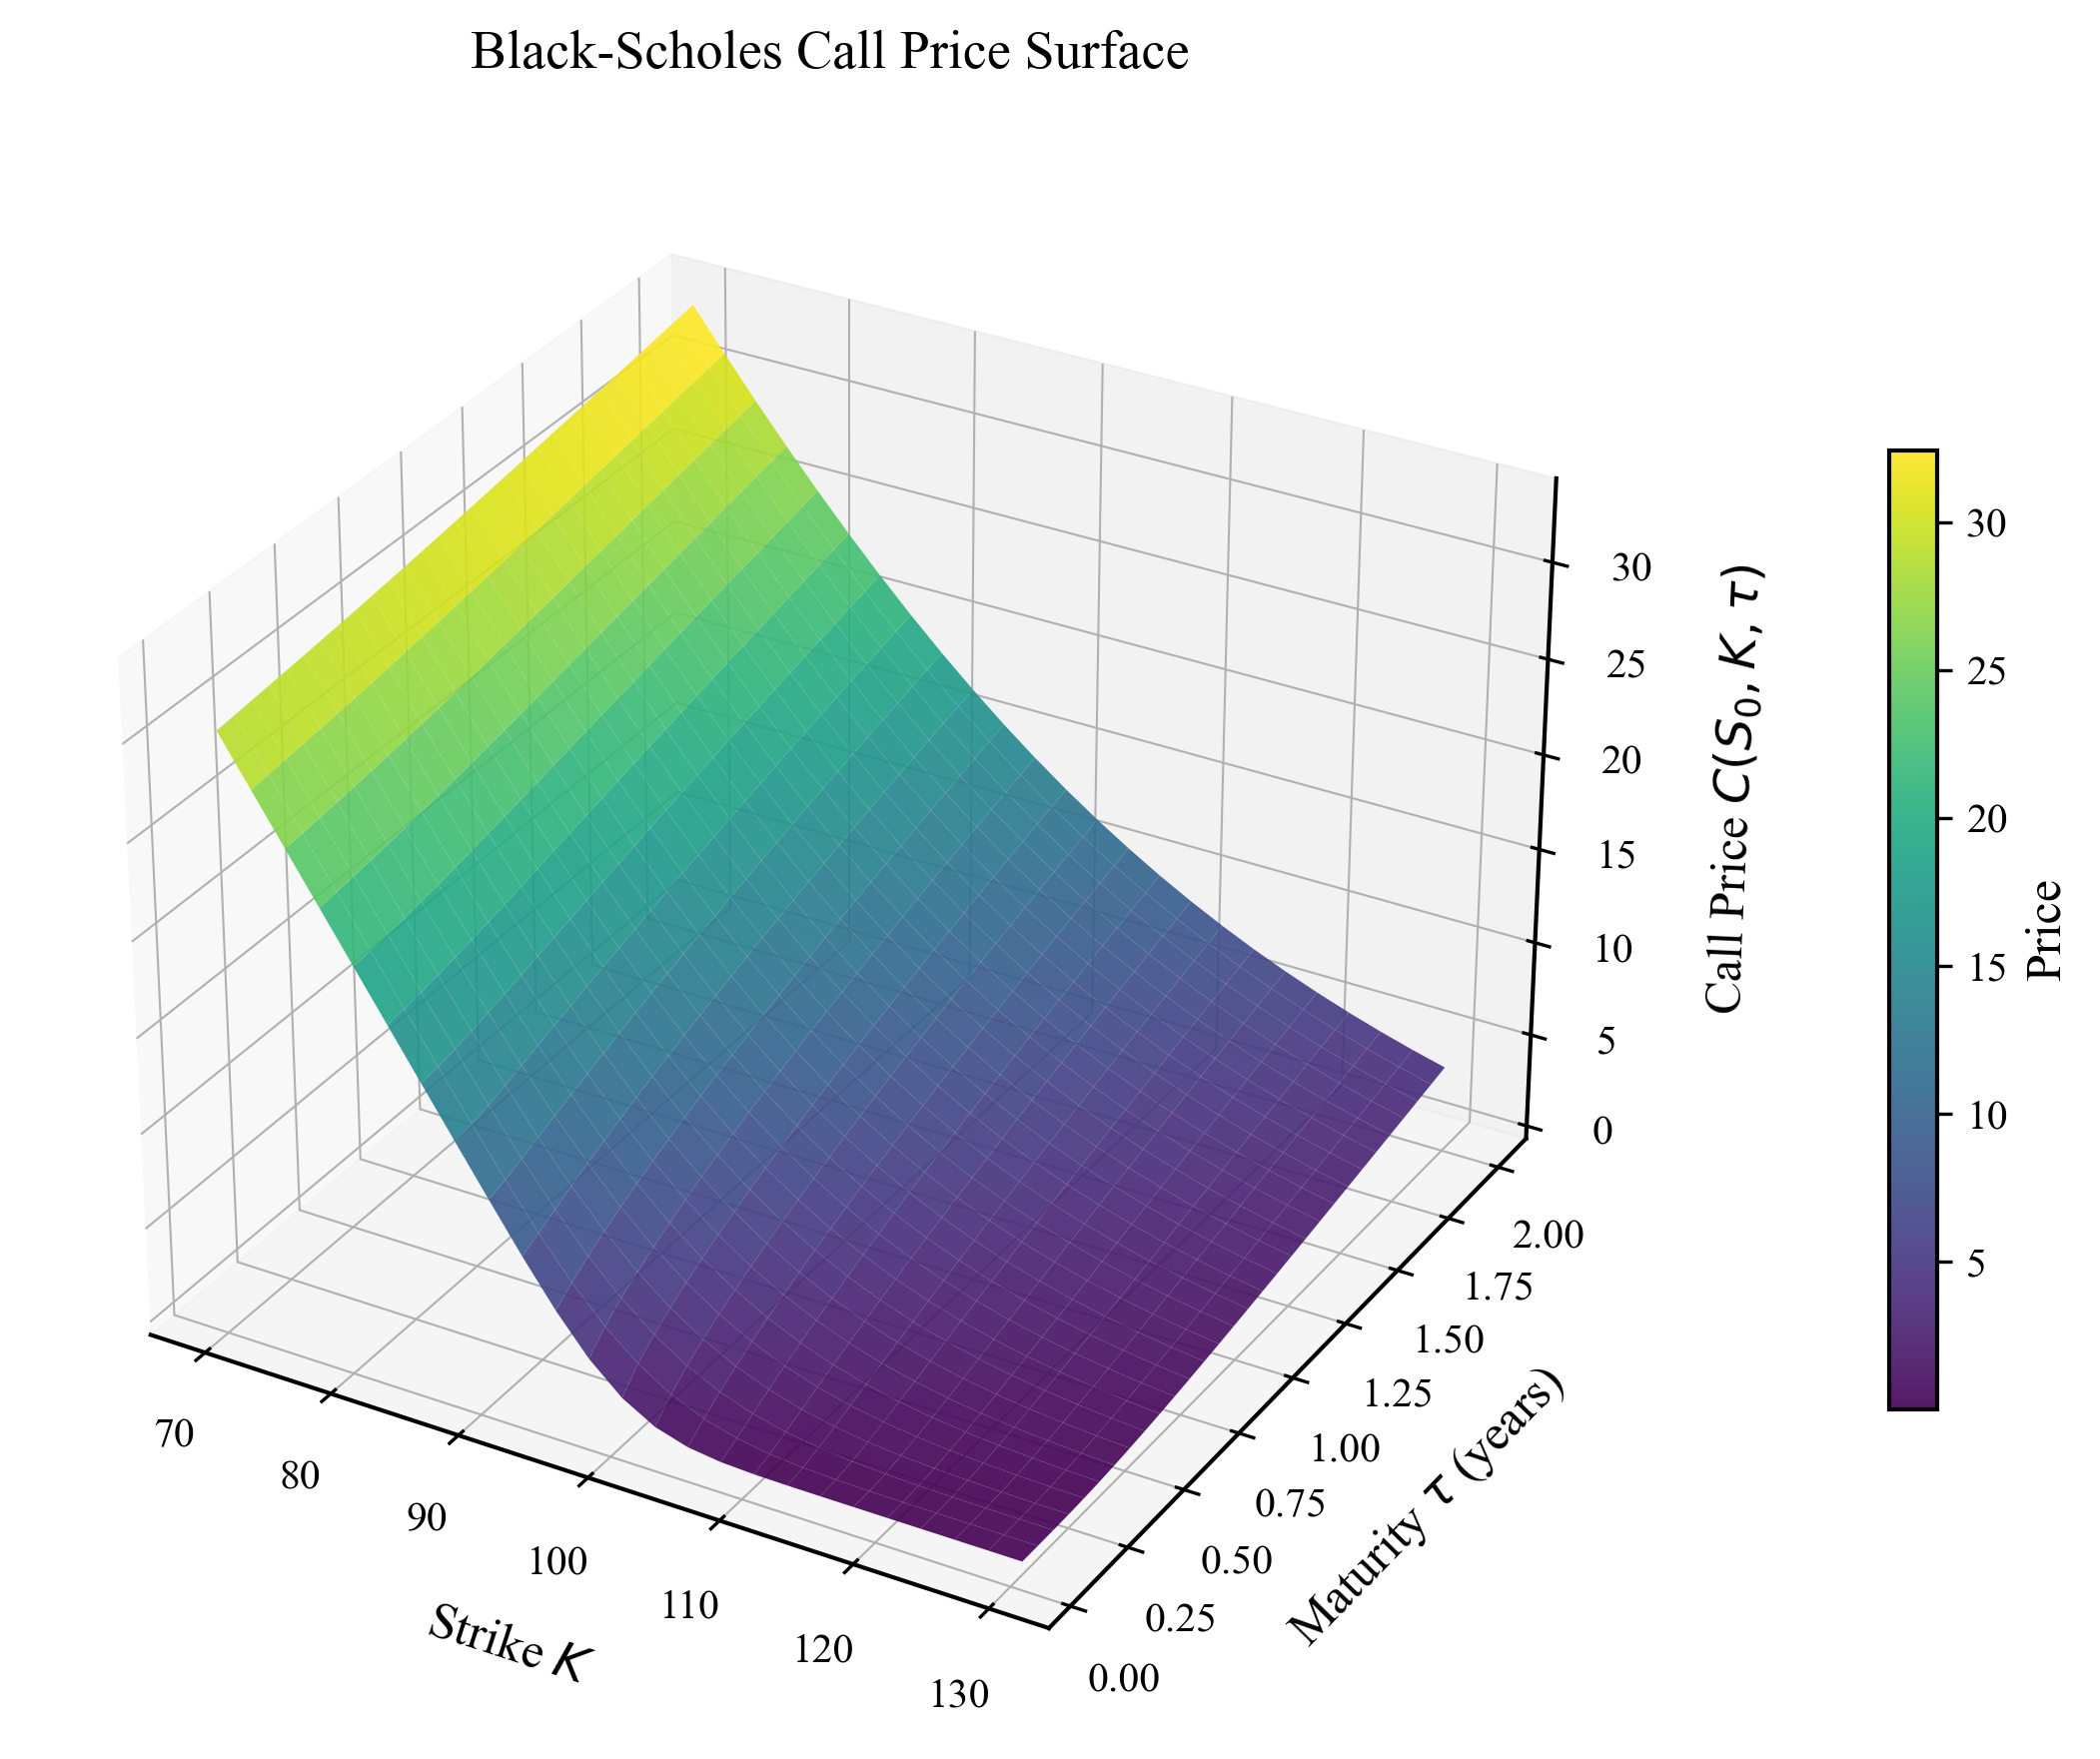

In [4]:
strikes = np.sort(np.linspace(70, 130, 25))
maturities = np.sort(np.linspace(0.05, 2.0, 30))

prices = np.zeros((len(maturities), len(strikes)))
impl_vols = np.zeros_like(prices)

for i, tau in enumerate(maturities):
    for j, K in enumerate(strikes):
        price = bs.call_price(S0, K, tau)
        prices[i, j] = price
        impl_vols[i, j] = bs.sigma

# Matplotlib 3D surface for publication
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
K_grid, T_grid = np.meshgrid(strikes, maturities)
surf = ax.plot_surface(K_grid, T_grid, prices, cmap='viridis', alpha=0.9, 
                       linewidth=0, antialiased=True, edgecolor='none')
ax.set_xlabel(r'Strike $K$', fontsize=12, labelpad=8)
ax.set_ylabel(r'Maturity $\tau$ (years)', fontsize=12, labelpad=8)
ax.set_zlabel(r'Call Price $C(S_0, K, \tau)$', fontsize=12, labelpad=8)
ax.set_title('Black-Scholes Call Price Surface', fontsize=13, pad=15)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1, label='Price')
plt.tight_layout()
plt.savefig('../figures/bs_price_surface.png', dpi=300, bbox_inches='tight')
plt.show()

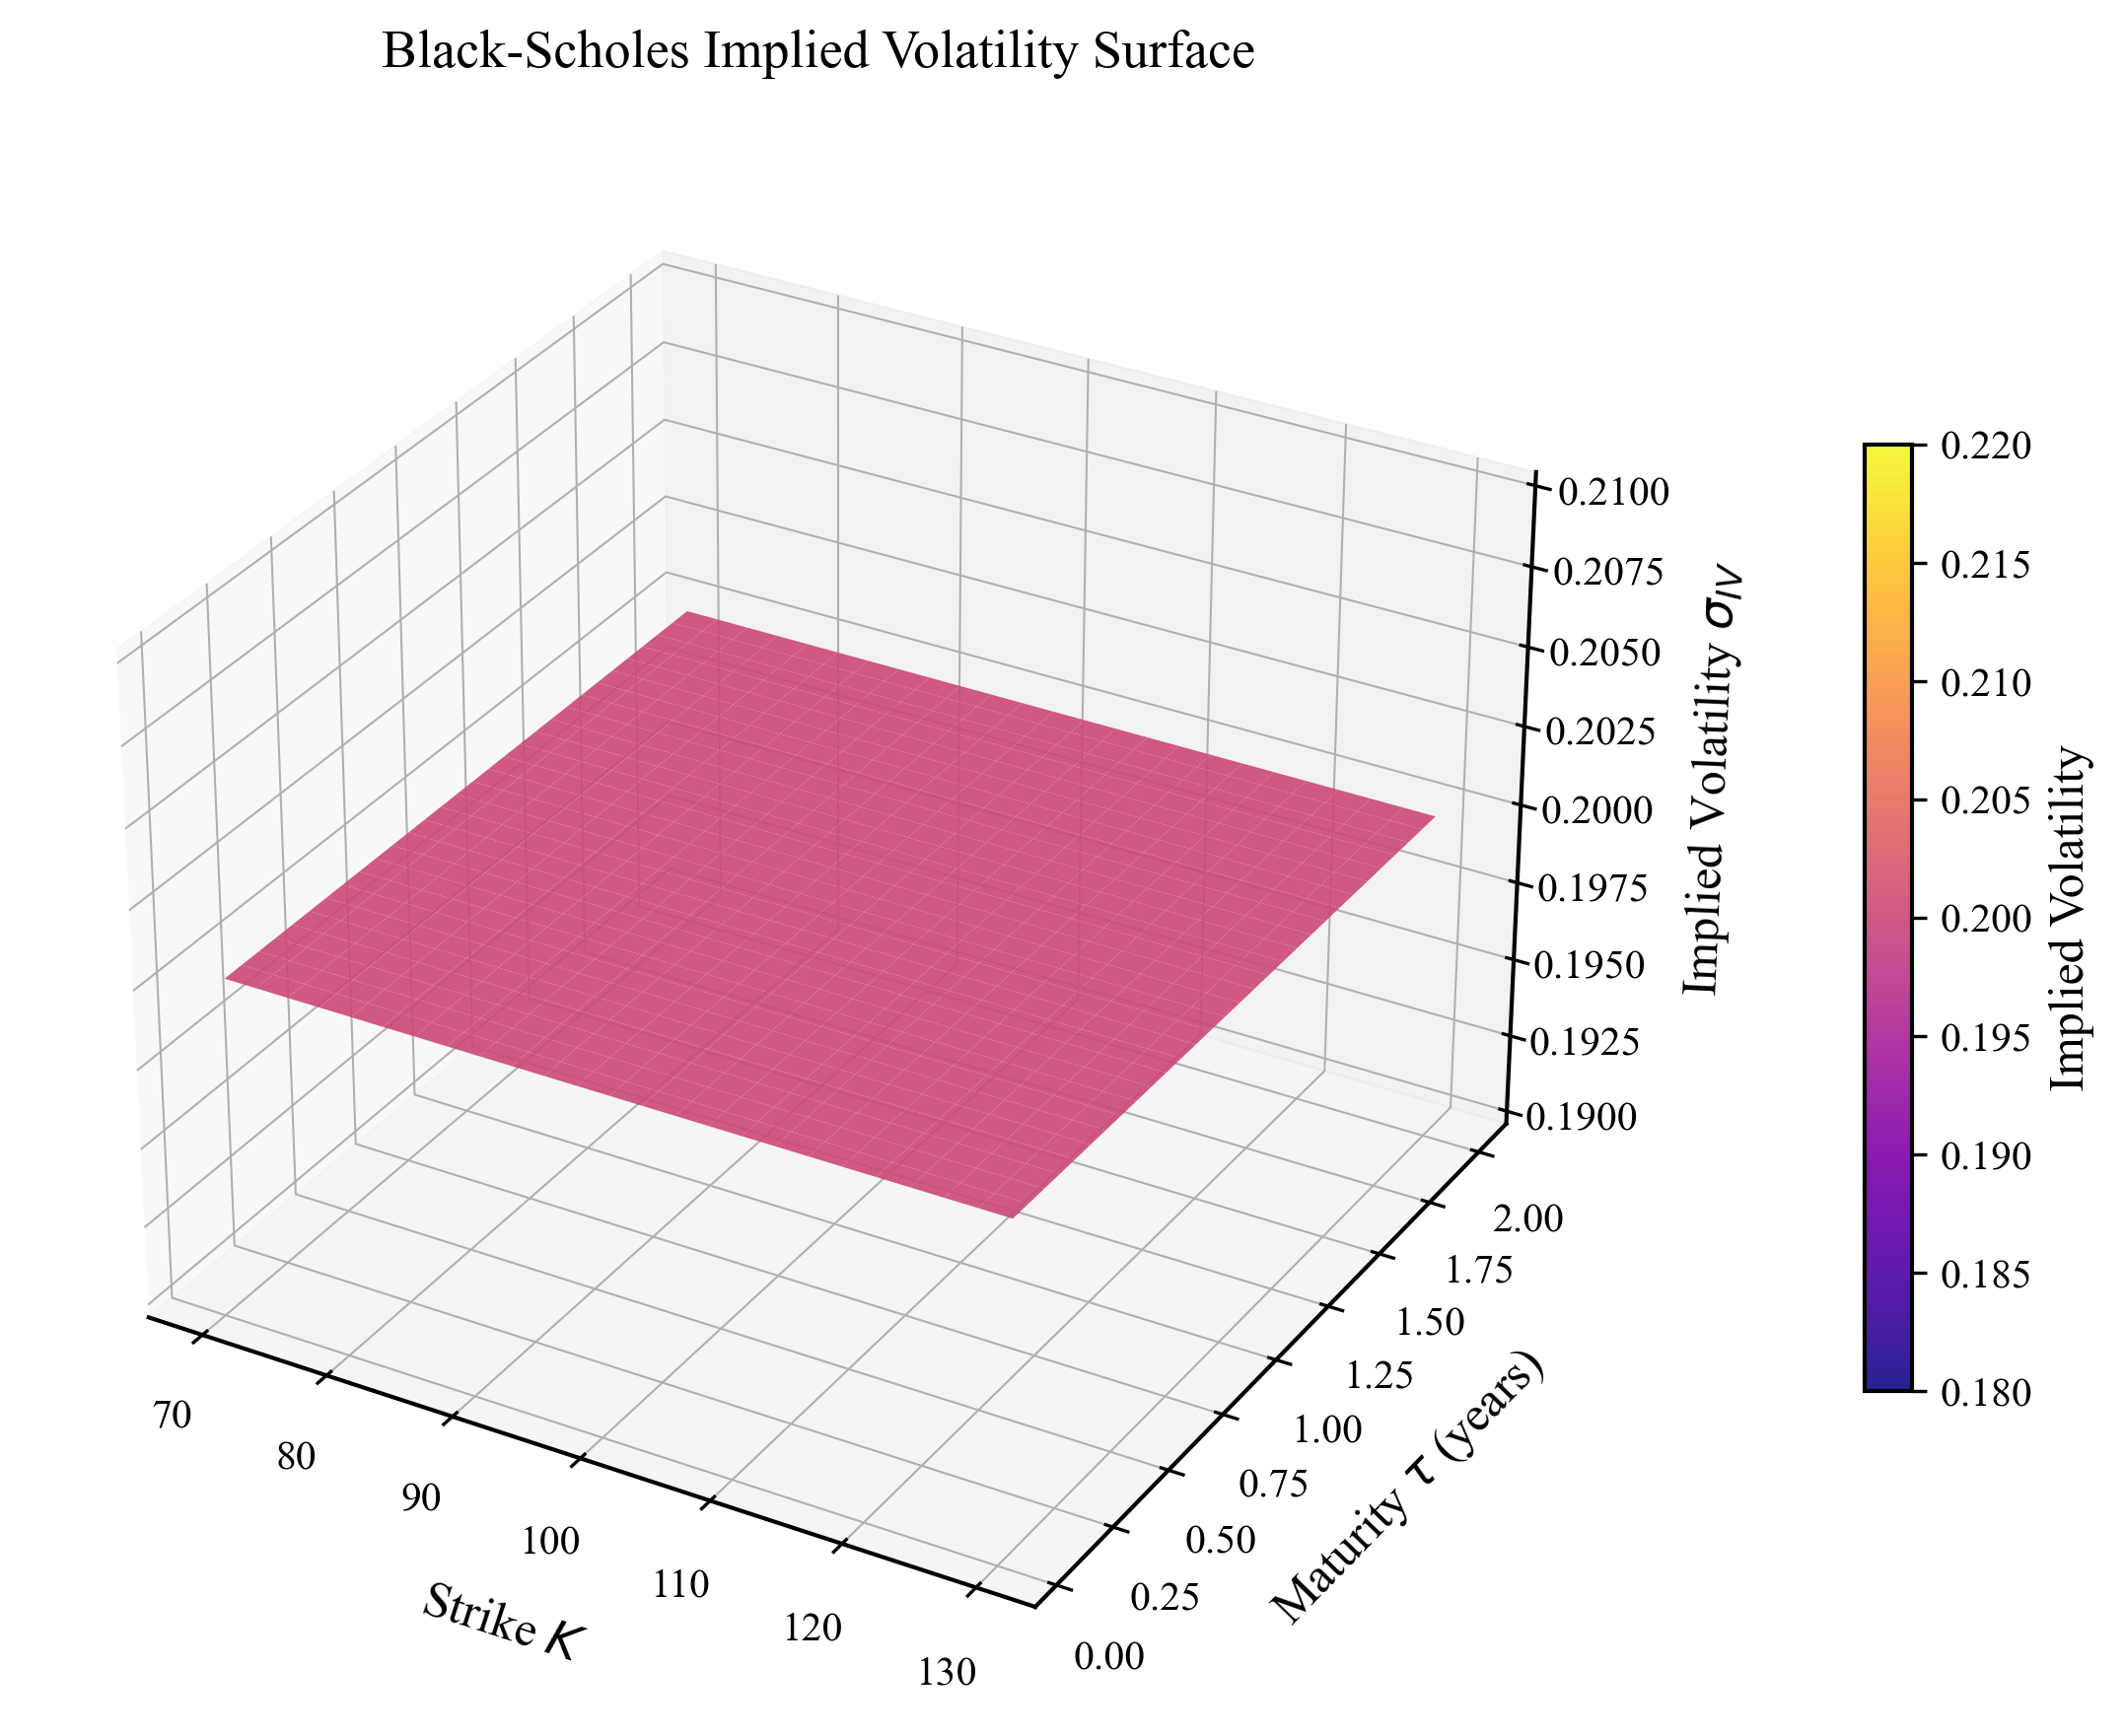

In [5]:
# Matplotlib 3D surface for publication
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K_grid, T_grid, impl_vols, cmap='plasma', alpha=0.9,
                       linewidth=0, antialiased=True, edgecolor='none')
ax.set_xlabel(r'Strike $K$', fontsize=12, labelpad=8)
ax.set_ylabel(r'Maturity $\tau$ (years)', fontsize=12, labelpad=8)
ax.set_zlabel(r'Implied Volatility $\sigma_{IV}$', fontsize=12, labelpad=8)
ax.set_title('Black-Scholes Implied Volatility Surface', fontsize=13, pad=15)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1, label='Implied Volatility')
plt.tight_layout()
plt.savefig('../figures/bs_iv_surface.png', dpi=300, bbox_inches='tight')
plt.show()

## Parameter sensitivity

Since Black–Scholes has a single volatility parameter, we can sweep `sigma` to see how prices and greeks respond.


In [7]:
sigmas = np.linspace(0.1, 0.6, 10)
prices_sigma = []
greeks_sigma = []
for s in sigmas:
    model = BlackScholesModel(sigma=s, r=r, q=q)
    price = model.call_price(S0, 100, 1.0)
    greeks = model.greeks(S0, 100, 1.0)
    prices_sigma.append(price)
    greeks_sigma.append(greeks)
prices_sigma = np.array(prices_sigma)
deltas = [g["delta"] for g in greeks_sigma]
vegas = [g["vega"] for g in greeks_sigma]
prices_sigma[:5]

array([ 5.01698061,  7.17876427,  9.35052057, 11.52142039, 13.68694663])

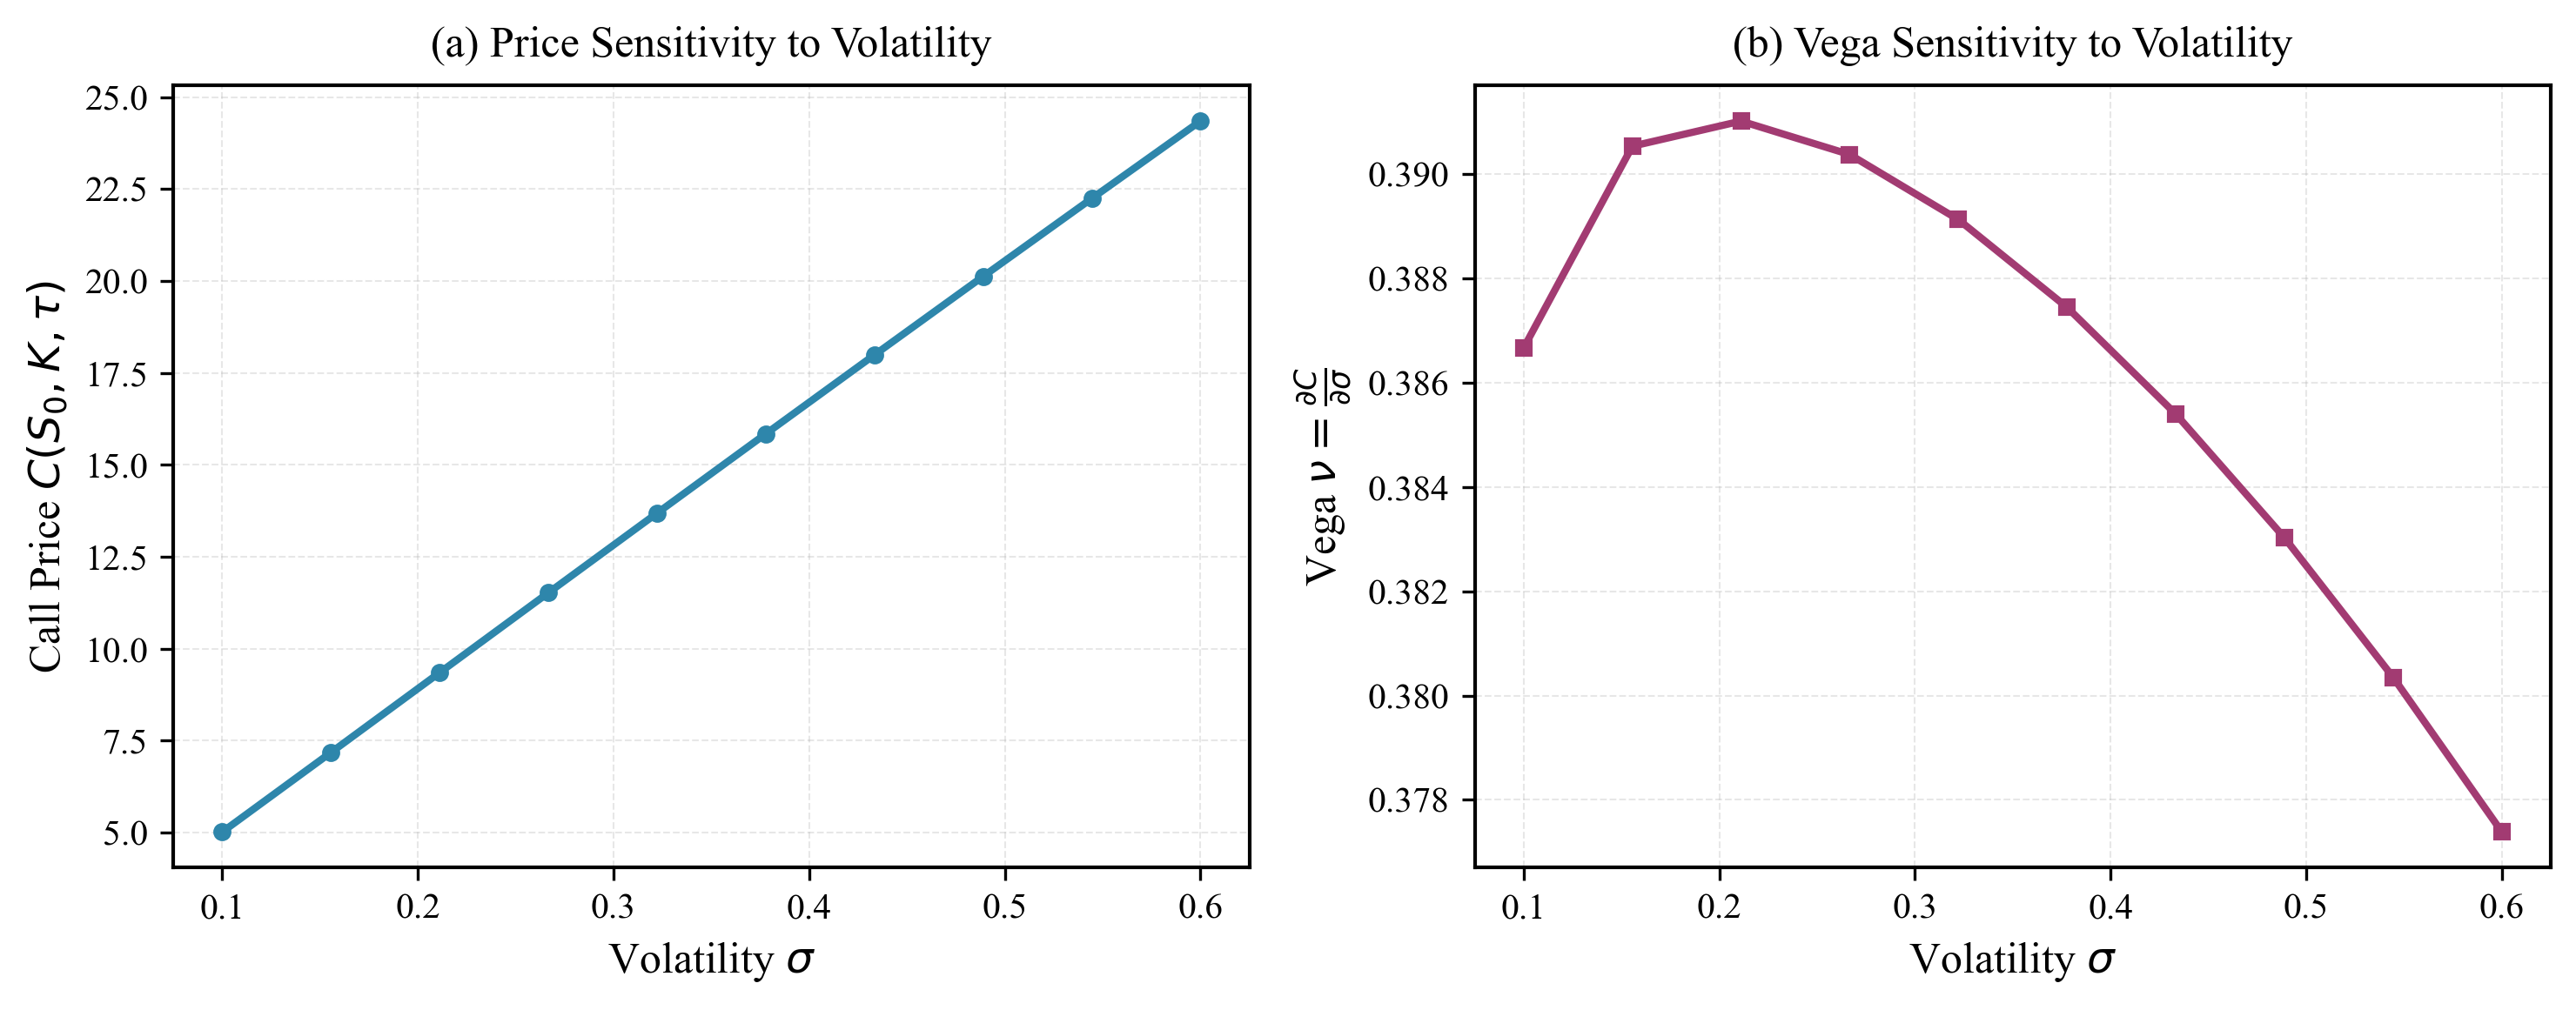

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Price sensitivity
ax[0].plot(sigmas, prices_sigma, color=COLORS['primary'], linewidth=2, marker='o', markersize=4)
ax[0].set_xlabel(r'Volatility $\sigma$', fontsize=12)
ax[0].set_ylabel(r'Call Price $C(S_0, K, \tau)$', fontsize=12)
ax[0].set_title('(a) Price Sensitivity to Volatility', fontsize=12, pad=8)
ax[0].grid(True, alpha=0.3, linestyle='--')

# Vega sensitivity
ax[1].plot(sigmas, vegas, color=COLORS['secondary'], linewidth=2, marker='s', markersize=4)
ax[1].set_xlabel(r'Volatility $\sigma$', fontsize=12)
ax[1].set_ylabel(r'Vega $\nu = \frac{\partial C}{\partial \sigma}$', fontsize=12)
ax[1].set_title('(b) Vega Sensitivity to Volatility', fontsize=12, pad=8)
ax[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/bs_parameter_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

## Moments vs. Black–Scholes

We simulate log-returns under Black–Scholes (i.e., geometric Brownian motion) and compare their sample moments to the true lognormal/normal distribution. This provides a baseline for the richer Heston dynamics.


In [9]:
T = 1.0
n_steps = 252
n_paths = 20000
dt = T / n_steps
rng = np.random.default_rng(123)

log_returns = np.zeros(n_paths)
for i in range(n_paths):
    shocks = rng.standard_normal(n_steps)
    path = (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
    log_returns[i] = path.sum()

sample_mean = log_returns.mean()
sample_std = log_returns.std(ddof=1)
sample_skew = ((log_returns - sample_mean) ** 3).mean() / sample_std**3
sample_kurt = ((log_returns - sample_mean) ** 4).mean() / sample_std**4

sample_mean, sample_std, sample_skew, sample_kurt

(np.float64(0.0015533537683216573),
 np.float64(0.19857625585389752),
 np.float64(0.0054248328633484345),
 np.float64(2.985179601383576))

For a normal distribution we expect skew = 0 and kurtosis = 3; the Monte Carlo estimates confirm that the log-return distribution under Black–Scholes remains close to Gaussian, unlike the Heston simulations shown earlier.


### Comparison checklist

- The price/vol surfaces are flat in strike because BS assumes constant volatility.
- Parameter sensitivity reduces to a single knob (`sigma`).
- Moments remain Gaussian, providing a baseline to contrast with the richer Heston moments.